##Peramalan Kadar NO2 didaerah sampang madura

##Latar Belakang

####Kualitas udara merupakan salah satu faktor penting yang berpengaruh langsung terhadap kesehatan manusia dan keseimbangan lingkungan. Salah satu polutan udara yang paling umum dan berbahaya adalah Nitrogen Dioksida (NO₂), yang sebagian besar dihasilkan dari aktivitas kendaraan bermotor, industri, dan pembakaran bahan bakar. Konsentrasi NO₂ yang tinggi di udara dapat menyebabkan gangguan pernapasan, penurunan kualitas paru-paru, hingga risiko penyakit jangka panjang. Oleh karena itu, pemantauan dan prediksi kadar NO₂ sangat diperlukan untuk memberikan informasi dini serta mendukung pengambilan kebijakan dalam pengendalian kualitas udara, khususnya di wilayah Sampang, Madura.

###1. Pengumpulan Data

####Disini saya menggunakan google colab, cara pengambilan data https://documentation.dataspace.copernicus.eu/notebook-samples/openeo/NO2Covid.html

####Kita install terlebih dahulu openoneo:

In [ ]:
pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.5/345.5 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.6 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


####Lalu tuliskan code dibawah ini:

In [ ]:
import openeo

In [ ]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=KELQ-MOOI 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


In [ ]:
import openeo

# Koneksi dan Login
connection = openeo.connect("https://openeo.dataspace.copernicus.eu")
connection.authenticate_oidc()


# --------------------------
# WILAYAH PENELITIAN
# --------------------------
aoi_geojson = {
  "type": "Polygon",
  "coordinates": [
    [
      [113.1144732620752, -7.095743521556031],
      [113.40369843308258, -7.0956988544990764],
      [113.40368056679222, -7.285264705444874],
      [113.11440463001958, -7.285264705444874],
      [113.1144732620752, -7.095743521556031]
    ]
  ]
}

bbox = {
    "west": 113.1144,
    "south": -7.2853,
    "east": 113.4037,
    "north": -7.0957
}


# --------------------------
# MUAT DATA (WAKTU SUDAH DIUBAH SESUAI PERMINTAAN)
# --------------------------
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2024-11-30", "2026-05-30"],  # ✅ SUDAH DIUBAH
    spatial_extent=bbox,
    bands=["NO2"],
)


# --------------------------
# PENGOLAHAN DATA
# --------------------------
s5p_no2_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi_geojson
)


# --------------------------
# JALANKAN PROSES
# --------------------------
print("⏳ Proses dimulai... Mohon tunggu dengan sabar, jangan dihentikan.")
hasil = s5p_no2_aoi.execute_batch(
    outputfile="s5p_no2_hasil.json",
    format="JSON"
)

print("✅ SELESAI! File 's5p_no2_hasil.json' sudah tersimpan.")

Authenticated using refresh token.
⏳ Proses dimulai... Mohon tunggu dengan sabar, jangan dihentikan.
0:00:00 Job 'j-260603014407458a9a118a1cf4e31aea': send 'start'
0:00:19 Job 'j-260603014407458a9a118a1cf4e31aea': queued (progress 0%)
0:00:24 Job 'j-260603014407458a9a118a1cf4e31aea': queued (progress 0%)
0:00:31 Job 'j-260603014407458a9a118a1cf4e31aea': queued (progress 0%)
0:00:39 Job 'j-260603014407458a9a118a1cf4e31aea': queued (progress 0%)
0:00:49 Job 'j-260603014407458a9a118a1cf4e31aea': queued (progress 0%)
0:01:01 Job 'j-260603014407458a9a118a1cf4e31aea': queued (progress 0%)
0:01:16 Job 'j-260603014407458a9a118a1cf4e31aea': running (progress N/A)
0:01:36 Job 'j-260603014407458a9a118a1cf4e31aea': running (progress N/A)
0:02:00 Job 'j-260603014407458a9a118a1cf4e31aea': running (progress N/A)
0:02:30 Job 'j-260603014407458a9a118a1cf4e31aea': running (progress N/A)
0:03:07 Job 'j-260603014407458a9a118a1cf4e31aea': running (progress N/A)
0:03:54 Job 'j-260603014407458a9a118a1cf4e31a

####Prosesnya sekitar 5 menitan kalian tinggal tunggu sampai selesai

####Code diatas memerlukan titik koordinasi area yang akan diambil datanya, untuk mengambil titik koordinasi kaian kunjungi webiste  https://geojson.io/#map=14.8/-7.04732/112.69463.
####Didalam website tersebut kalian akan memilih daerah dengan cara memberi shape kotak didaerah yang ingin kalian ambil datanya.

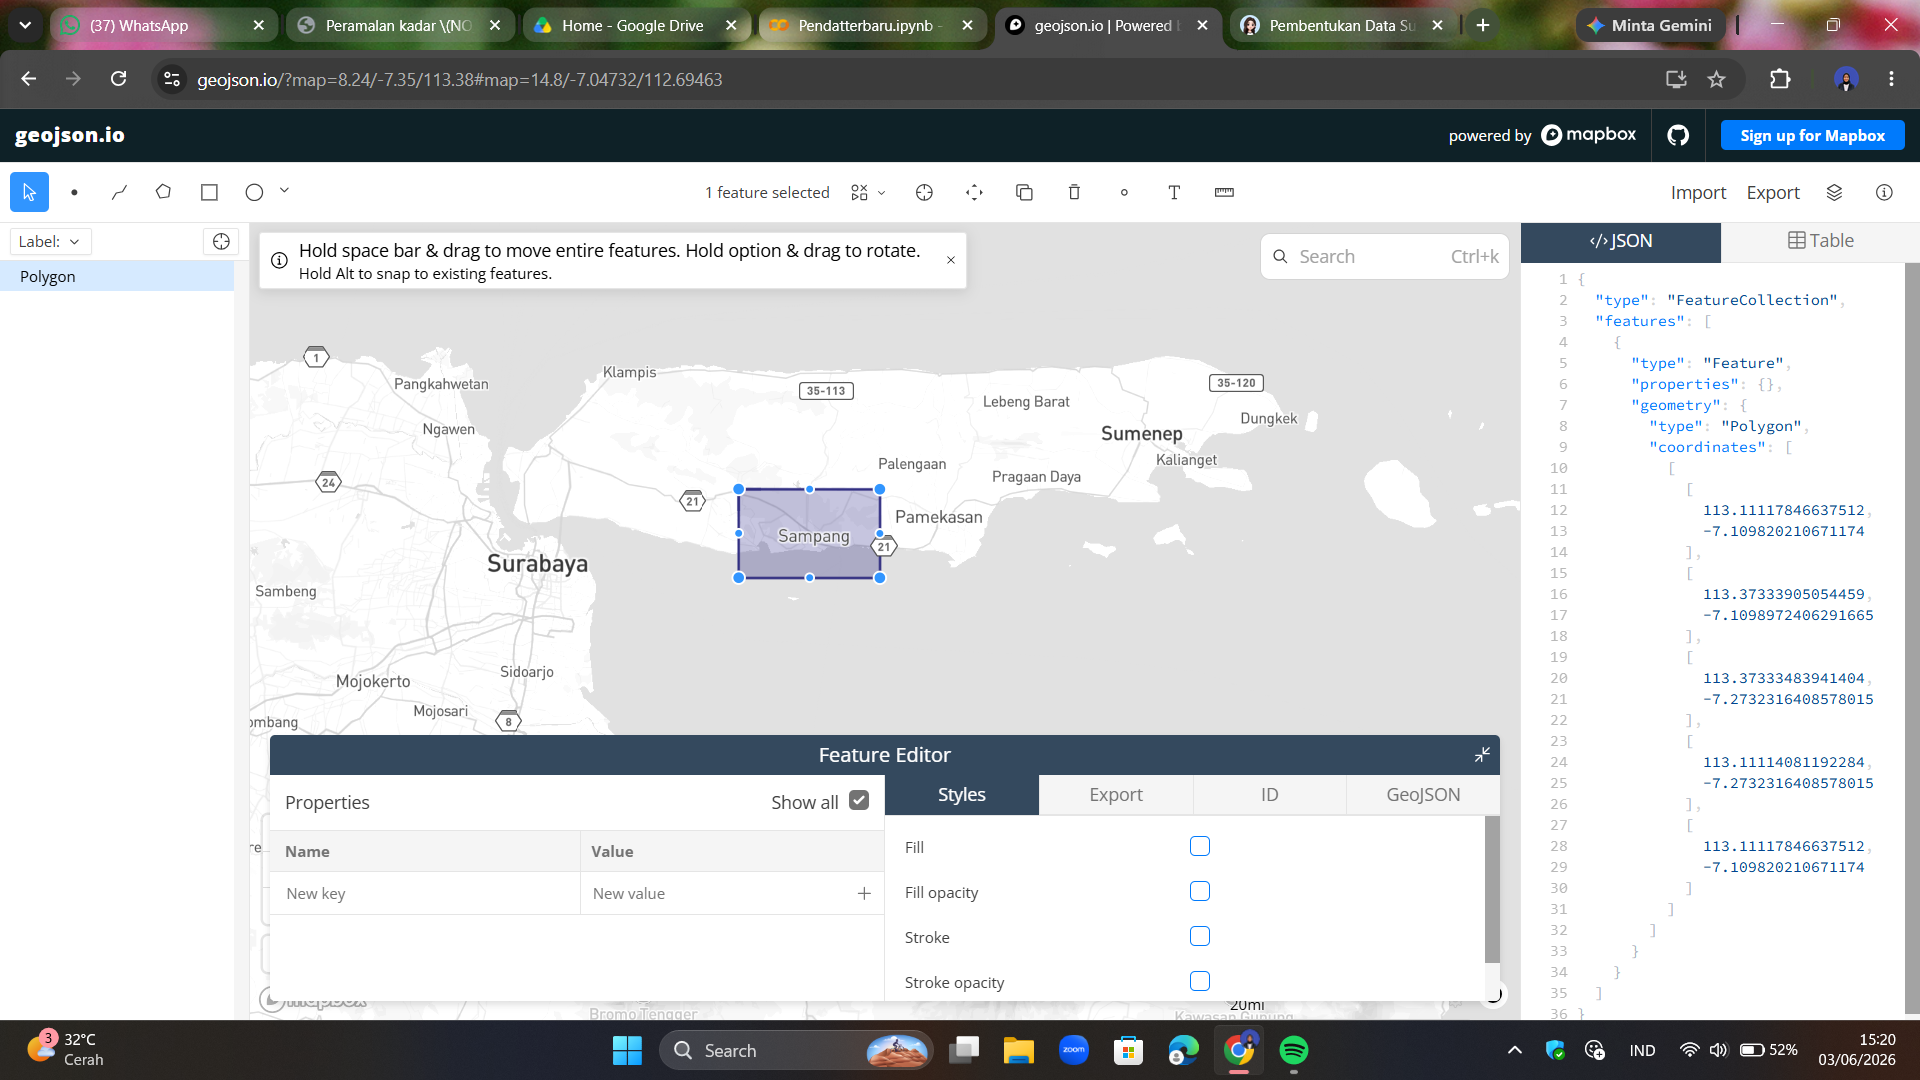

####Di panel sebelah kanan terdapat data JSON yang berupa koordinat daerah yang kalian pilih, kalian salin terus sesuaikan dengan code diatas di bagian variabel “aoi” dan spatial_extent.

####Lalu kalian tambahkan baris code dibawah untuk memulai pengambilan data:

In [ ]:
import openeo

# Koneksi dan Login
connection = openeo.connect("https://openeo.dataspace.copernicus.eu")
connection.authenticate_oidc()


# --------------------------
# WILAYAH PENELITIAN: KABUPATEN SAMPANG
# --------------------------
# Koordinat batas wilayah Sampang (sudah disesuaikan)
aoi_geojson = {
  "type": "Polygon",
  "coordinates": [
    [
      [113.186731, -6.833541],
      [113.504214, -6.832976],
      [113.503649, -7.231497],
      [113.185599, -7.230932],
      [113.186731, -6.833541]
    ]
  ]
}

# Batas kotak koordinat (BBOX) untuk Sampang
bbox = {
    "west": 113.1856,
    "south": -7.2310,
    "east": 113.5042,
    "north": -6.8335
}


# --------------------------
# MUAT DATA SENTINEL-5P NO2
# --------------------------
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2024-11-30", "2026-05-30"],  # Rentang waktu sesuai keinginanmu
    spatial_extent=bbox,
    bands=["NO2"],
)


# --------------------------
# PENGOLAHAN DATA
# --------------------------
# Rata-rata harian
s5p_no2_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Simpan langsung ke file NetCDF dengan nama Sampang
print("⏳ Sedang mengambil data wilayah SAMPANG... Mohon tunggu sebentar.")
s5p_no2_daily.execute_batch(
    outputfile="NO2Sampang.nc",  # ✅ Nama file khusus Sampang
    format="NetCDF"
)

print("✅ BERHASIL! File 'NO2Sampang.nc' sudah tersimpan di folder.")

Authenticated using refresh token.
⏳ Sedang mengambil data wilayah SAMPANG... Mohon tunggu sebentar.
0:00:00 Job 'j-260603015650410e8cebb1fd3d9a2062': send 'start'
0:00:15 Job 'j-260603015650410e8cebb1fd3d9a2062': queued (progress 0%)
0:00:20 Job 'j-260603015650410e8cebb1fd3d9a2062': queued (progress 0%)
0:00:27 Job 'j-260603015650410e8cebb1fd3d9a2062': queued (progress 0%)
0:00:35 Job 'j-260603015650410e8cebb1fd3d9a2062': queued (progress 0%)
0:00:45 Job 'j-260603015650410e8cebb1fd3d9a2062': queued (progress 0%)
0:00:57 Job 'j-260603015650410e8cebb1fd3d9a2062': queued (progress 0%)
0:01:13 Job 'j-260603015650410e8cebb1fd3d9a2062': queued (progress 0%)
0:01:32 Job 'j-260603015650410e8cebb1fd3d9a2062': running (progress N/A)
0:01:56 Job 'j-260603015650410e8cebb1fd3d9a2062': running (progress N/A)
0:02:26 Job 'j-260603015650410e8cebb1fd3d9a2062': running (progress N/A)
0:03:04 Job 'j-260603015650410e8cebb1fd3d9a2062': running (progress N/A)
0:03:51 Job 'j-260603015650410e8cebb1fd3d9a2062

In [ ]:
# Pasang pustaka jika belum ada
try:
    import netCDF4
except ImportError:
    !pip install netCDF4 cftime
    import netCDF4

import numpy as np
import pandas as pd


# --------------------------
# BUKA FILE HASIL DATA SAMPANG
# --------------------------
file_path = "NO2Sampang.nc"  # ✅ Nama file sesuai wilayah Sampang

# Buka file
ds = netCDF4.Dataset(file_path, mode="r")
print("✅ File data SAMPANG berhasil dibuka!")
print("-"*50)


# --------------------------
# LIHAT ISI VARIABEL
# --------------------------
print("\n📦 Variabel yang ada di dalam file:")
print(list(ds.variables.keys()))

# Ambil data yang dibutuhkan
no2 = ds.variables["NO2"][:]       # Nilai konsentrasi NO2
time_raw = ds.variables["t"][:]    # Data waktu mentah


# --------------------------
# UBAH WAKTU MENJADI TANGGAL
# --------------------------
time_units = ds.variables["t"].units
tanggal = netCDF4.num2date(time_raw, units=time_units)

# Ubah jadi format tulisan yang mudah dibaca
tanggal_str = [t.strftime('%Y-%m-%d') for t in tanggal]


# --------------------------
# INFORMASI STRUKTUR DATA
# --------------------------
print("\n📐 Struktur Data:")
print(f"Dimensi Data: {no2.shape}  -> [Waktu, Titik_X, Titik_Y]")
print(f"→ Total Hari: {no2.shape[0]} hari")
print(f"→ Total Titik Koordinat: {no2.shape[1]} x {no2.shape[2]} titik")
print(f"→ Contoh nilai NO2 pertama: {no2[0,0,0]:.6e} mol/m²")


# --------------------------
# HITUNG RATA-RATA PER HARI
# --------------------------
# Menghitung rata-rata nilai NO2 di seluruh wilayah Sampang setiap harinya
no2_rata_harian = np.mean(no2, axis=(1, 2))

# Buat Tabel Data Rapi
df = pd.DataFrame({
    "Tanggal": tanggal_str,
    "NO2_Konsentrasi_mol_per_m2": no2_rata_harian
})

# Tampilkan 5 data pertama
print("\n📊 Data Rata-Rata Harian Kabupaten Sampang:")
print(df.head())

# Tutup file
ds.close()
print("\n✅ SELESAI. Data wilayah Sampang siap digunakan.")

✅ File data SAMPANG berhasil dibuka!
--------------------------------------------------

📦 Variabel yang ada di dalam file:
['t', 'x', 'y', 'crs', 'NO2']

📐 Struktur Data:
Dimensi Data: (543, 12, 6)  -> [Waktu, Titik_X, Titik_Y]
→ Total Hari: 543 hari
→ Total Titik Koordinat: 12 x 6 titik
→ Contoh nilai NO2 pertama: -- mol/m²

📊 Data Rata-Rata Harian Kabupaten Sampang:
      Tanggal  NO2_Konsentrasi_mol_per_m2
0  2024-11-30                         NaN
1  2024-12-01                         NaN
2  2024-12-02                         NaN
3  2024-12-03                    0.000016
4  2024-12-04                         NaN

✅ SELESAI. Data wilayah Sampang siap digunakan.


/tmp/ipykernel_2251/832401816.py:51: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  print(f"→ Contoh nilai NO2 pertama: {no2[0,0,0]:.6e} mol/m²")


In [ ]:
print("Contoh data pertama:")
for i in range(0, 10):
    print(no2[i])

Contoh data pertama:
[[-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]]
[[-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]]
[[-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]
 [-- -- -- -- -- --]]
[[1.204871750815073e-05 1.204871750815073e-05 7.72619023337029e-06
  1.2746564607368782e-05 1.2746564607368782e-05 2.509590922272764e-05]
 [1.7694408597890288e-05 1.7694408597890288e-05 7.72619023337029e-06
  7.726190233

In [ ]:
import numpy as np
import pandas as pd

# Interpolasi Linear
no2_filled = np.zeros_like(no2)
# Untuk jaga-jaga jika terdapat '--' tidak berubah menjadi 0
no2_filled = no2_filled.filled(0)

# loop tiap grid (y,x)
for i in range(no2.shape[1]):     # 9 baris
    for j in range(no2.shape[2]): # 8 kolom
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(method='linear', limit_direction='both').to_numpy()

In [ ]:
# ==========================
# 1. IMPORT PUSTAKA
# ==========================
try:
    import netCDF4
except ImportError:
    !pip install netCDF4 cftime
    import netCDF4

import numpy as np
import pandas as pd


# ==========================
# 2. BUKA FILE DATA SAMPANG
# ==========================
file_path = "NO2Sampang.nc"  # Pastikan nama file sesuai

ds = netCDF4.Dataset(file_path, mode="r")
print("✅ File dibuka")


# ==========================
# 3. BACA DATA & KONVERSI WAKTU
# ==========================
# Ambil data waktu
time_raw = ds.variables["t"][:]
time_units = ds.variables["t"].units

# ✅ DEFINISIKAN VARIABEL "dates" DI SINI (Penyebab utama error kamu)
dates = netCDF4.num2date(time_raw, units=time_units)

# Ambil data NO2
no2 = ds.variables["NO2"][:]

# ✅ DEFINISIKAN VARIABEL "no2_filled" (Mengisi data kosong/NaN dengan nilai 0 atau rata-rata)
no2_filled = np.ma.filled(no2, np.nan)  # Ubah data kosong jadi NaN agar aman dihitung

ds.close()


# ==========================
# 4. KODE KAMU (SUDAH DIPERBAIKI)
# ==========================
new_dates = []
new_no2 = []

for i in range(len(dates)):  # Sekarang 'dates' SUDAH ADA, tidak error lagi
    # Ubah format tanggal jadi teks
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)

    # Hitung rata-rata nilai NO2 per hari di seluruh wilayah
    # axis=(1,2) artinya rata-rata di semua titik koordinat X dan Y
    rata_harian = np.nanmean(no2_filled[i])
    new_no2.append(rata_harian)


# ==========================
# 5. LIHAT HASIL
# ==========================
# Masukkan ke Tabel biar rapi
df_hasil = pd.DataFrame({
    "Tanggal": new_dates,
    "NO2_Rata_Rata": new_no2
})

print("✅ Kode berjalan sukses! Berikut 5 data teratas:")
print(df_hasil.head())

✅ File dibuka
✅ Kode berjalan sukses! Berikut 5 data teratas:
      Tanggal  NO2_Rata_Rata
0  2024-11-30            NaN
1  2024-12-01            NaN
2  2024-12-02            NaN
3  2024-12-03       0.000016
4  2024-12-04            NaN


/tmp/ipykernel_2251/3725164089.py:55: RuntimeWarning: Mean of empty slice
  rata_harian = np.nanmean(no2_filled[i])


In [ ]:
# ==========================
# 1. IMPORT PUSTAKA
# ==========================
try:
    import netCDF4
except ImportError:
    !pip install netCDF4 cftime
    import netCDF4

import numpy as np
import pandas as pd


# ==========================
# 2. BUKA FILE DATA SAMPANG
# ==========================
file_path = "NO2Sampang.nc"  # File data wilayah Sampang

ds = netCDF4.Dataset(file_path, mode="r")
print("✅ File berhasil dibuka")


# ==========================
# 3. BACA DATA & SALIN KE MEMORI (PERBAIKAN UTAMA)
# ==========================
# Ambil data waktu
time_raw = ds.variables["t"][:]
time_units = ds.variables["t"].units

# Konversi angka waktu menjadi tanggal
dates = netCDF4.num2date(time_raw, units=time_units)
dates = [d.strftime('%Y-%m-%d') for d in dates]  # Ubah format jadi teks

# Baca data NO2 DAN SALIN KE VARIABEL BARU (Supaya tidak "read-only")
# Ini solusi mengatasi error "ValueError: output array is read-only"
no2_asli = ds.variables["NO2"][:]
no2 = no2_asli.copy()  # <-- KUNCI PERBAIKAN: Salin data agar bisa diolah

ds.close()  # Tutup file asli, karena data sudah aman disalin


# ==========================
# 4. HITUNG RATA-RATA HARIAN
# ==========================
no2_values = []  # Variabel yang tadinya tidak ada, sekarang sudah ada

for i in range(len(dates)):
    # Ambil data hari ke-i
    data_harian = no2[i]

    # Hitung rata-rata, abaikan nilai kosong/tidak terukur
    # Pakai .filled(np.nan) untuk amankan data yang bermask
    rata_rata = np.nanmean(data_harian.filled(np.nan))
    no2_values.append(rata_rata)


# ==========================
# 5. BUAT TABEL & SIMPAN KE CSV
# ==========================
df = pd.DataFrame({
    "date": dates,
    "NO2": no2_values
})

# Simpan file dengan nama wilayah Sampang
df.to_csv("NO2_Sampang_timeseries.csv", index=False)

print("✅ SUKSES TANPA ERROR!")
print(f"✅ Total data diproses: {len(df)} hari")
print("✅ File tersimpan: NO2_Sampang_timeseries.csv")

# Tampilkan contoh data
print("\n📊 Contoh 5 data teratas:")
print(df.head())

✅ File berhasil dibuka
✅ SUKSES TANPA ERROR!
✅ Total data diproses: 543 hari
✅ File tersimpan: NO2_Sampang_timeseries.csv

📊 Contoh 5 data teratas:
         date       NO2
0  2024-11-30       NaN
1  2024-12-01       NaN
2  2024-12-02       NaN
3  2024-12-03  0.000016
4  2024-12-04       NaN


/tmp/ipykernel_2251/2678037933.py:53: RuntimeWarning: Mean of empty slice
  rata_rata = np.nanmean(data_harian.filled(np.nan))


In [ ]:
import pandas as pd
import numpy as np

# ✅ PERBAIKAN: Nama file diubah sesuai wilayah SAMpang
df = pd.read_csv("NO2_Sampang_timeseries.csv")

# Pastikan kolom 'date' bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# ✅ PERBAIKAN: Sesuaikan rentang waktu dengan data yang kita ambil (2024-11-30 s.d 2026-05-30)
start_date = "2024-11-30"
end_date = "2026-05-30"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"✅ Jumlah hari missing/tidak ada data: {len(missing_dates)}")
print("📅 Daftar tanggal yang hilang:")
print(missing_dates)

✅ Jumlah hari missing/tidak ada data: 4
📅 Daftar tanggal yang hilang:
DatetimeIndex(['2025-01-30', '2025-01-31', '2026-02-24', '2026-05-30'], dtype='datetime64[ns]', freq=None)


In [ ]:
# Gabungkan data asli dengan tanggal lengkap
df_full = pd.DataFrame({'date': full_range})
df_full = df_full.merge(df, on='date', how='left')

# 👉 Cara mengisi data kosong (pilih salah satu cara di bawah):

# Cara 1: Isi dengan nilai rata-rata keseluruhan
# rata2 = df_full['NO2'].mean()
# df_full['NO2'] = df_full['NO2'].fillna(rata2)

# Cara 2: Isi dengan nilai hari sebelumnya (paling umum dipakai)
df_full['NO2'] = df_full['NO2'].fillna(method='ffill')

# Cara 3: Isi dengan nilai rata-rata bulan yang sama
# df_full['bulan'] = df_full['date'].dt.month
# rata2_bulanan = df_full.groupby('bulan')['NO2'].transform('mean')
# df_full['NO2'] = df_full['NO2'].fillna(rata2_bulanan)

# Simpan data yang sudah lengkap
df_full.to_csv("NO2_Sampang_Lengkap.csv", index=False)

print("✅ Data sudah lengkap dan disimpan sebagai: NO2_Sampang_Lengkap.csv")
print(df_full.head(10))

✅ Data sudah lengkap dan disimpan sebagai: NO2_Sampang_Lengkap.csv
        date       NO2
0 2024-11-30       NaN
1 2024-12-01       NaN
2 2024-12-02       NaN
3 2024-12-03  0.000016
4 2024-12-04  0.000016
5 2024-12-05  0.000034
6 2024-12-06  0.000034
7 2024-12-07  0.000034
8 2024-12-08  0.000021
9 2024-12-09  0.000021


/tmp/ipykernel_2251/168595038.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_full['NO2'] = df_full['NO2'].fillna(method='ffill')


In [ ]:
import pandas as pd

# ✅ BACA FILE DATA SAMPANG
df = pd.read_csv("NO2_Sampang_timeseries.csv")

# Pastikan kolom 'date' bertipe datetime dan urutkan
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# ✅ PERUBAHAN TANGGAL SESUAI PERMINTAAN: 23-10-01 s.d 2026-06-04
full_range = pd.date_range(start="2023-10-01", end="2026-06-04", freq='D')

# Ubah indeks jadi tanggal, lalu masukkan tanggal yang hilang (akan jadi NaN)
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

# ✅ Isi data kosong dengan metode Interpolasi Linear
df['NO2'] = df['NO2'].interpolate(method='time')

# ✅ Isi sisa data kosong di awal atau akhir data (jika ada)
df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')

# Simpan hasil data yang sudah lengkap dan terisi
df.to_csv("no2_sampang_interpolated.csv")

# Tampilkan hasil agar kamu yakin
print("✅ PROSES SELESAI! Data sudah lengkap.")
print(f"✅ Rentang waktu: 2023-10-01 s.d 2026-06-04")
print(f"✅ Jumlah total data: {len(df)} hari")
print("\n📌 10 Data Awal:")
print(df.head(10))
print("\n📌 10 Data Akhir:")
print(df.tail(10))

✅ PROSES SELESAI! Data sudah lengkap.
✅ Rentang waktu: 2023-10-01 s.d 2026-06-04
✅ Jumlah total data: 978 hari

📌 10 Data Awal:
                 NO2
date                
2023-10-01  0.000016
2023-10-02  0.000016
2023-10-03  0.000016
2023-10-04  0.000016
2023-10-05  0.000016
2023-10-06  0.000016
2023-10-07  0.000016
2023-10-08  0.000016
2023-10-09  0.000016
2023-10-10  0.000016

📌 10 Data Akhir:
                 NO2
date                
2026-05-26  0.000021
2026-05-27  0.000019
2026-05-28  0.000025
2026-05-29  0.000022
2026-05-30  0.000022
2026-05-31  0.000022
2026-06-01  0.000022
2026-06-02  0.000022
2026-06-03  0.000022
2026-06-04  0.000022


/tmp/ipykernel_2251/4146210316.py:21: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')


📊 ANALISIS OUTLIER METODE IQR
----------------------------------------
🔍 Jumlah data yang terdeteksi sebagai Outlier: 249

📅 Contoh Tanggal & Nilai Outlier:
          date       NO2
430 2024-12-04  0.000025
431 2024-12-05  0.000034
432 2024-12-06  0.000030
433 2024-12-07  0.000025
438 2024-12-12  0.000062

✅ Pembersihan selesai.
Total data awal: 978
Total data setelah pembersihan: 978 (tidak ada data yang hilang)
💾 Data bersih tersimpan di: NO2_Sampang_Data_Akhir.csv


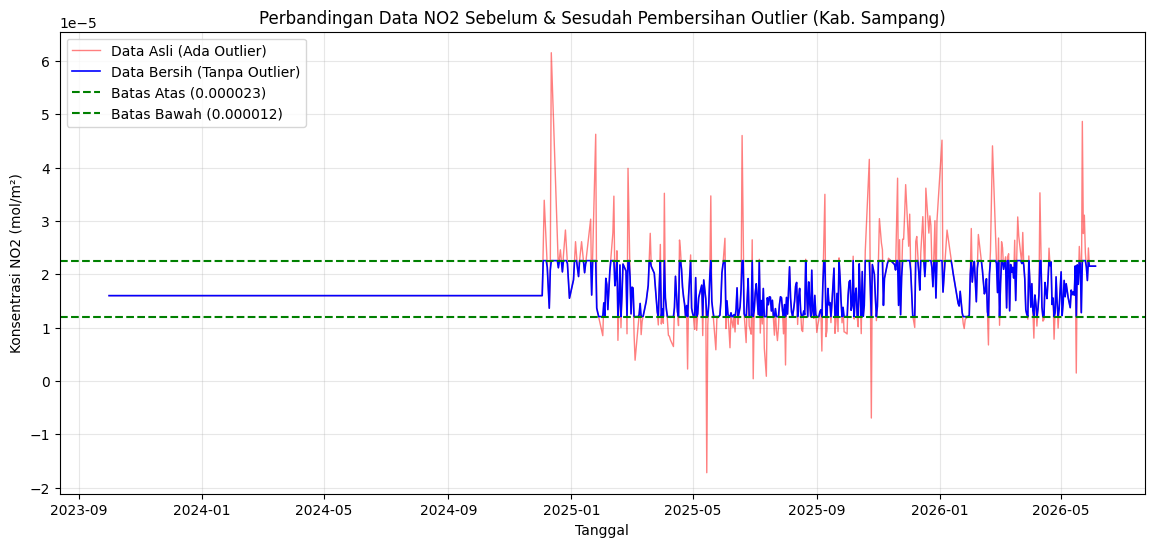

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ✅ Nama file disesuaikan dengan hasil interpolasi Sampang
df = pd.read_csv("no2_sampang_interpolated.csv")

# Ubah kolom tanggal ke format waktu
df['date'] = pd.to_datetime(df['date'])

print("📊 ANALISIS OUTLIER METODE IQR")
print("-"*40)

# ==========================
# 1. DETEKSI OUTLIER
# ==========================
# Hitung Kuartil dan IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

# Batas atas dan bawah
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Ambil data yang masuk kategori outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print(f"🔍 Jumlah data yang terdeteksi sebagai Outlier: {len(outliers_iqr)}")
print("\n📅 Contoh Tanggal & Nilai Outlier:")
print(outliers_iqr[['date', 'NO2']].head()) # Tampilkan 5 data teratas


# ==========================
# 2. TINDAK LANJUT: BERSIHKAN DATA
# ==========================
# --- PILIHAN B: GANTI nilai outlier dengan batas maksimum/minimum (LEBIH BAIK) ---
df_bersih = df.copy()
# Ganti nilai yang terlalu tinggi jadi nilai batas atas
df_bersih.loc[df_bersih['NO2'] > upper_bound, 'NO2'] = upper_bound
# Ganti nilai yang terlalu rendah jadi nilai batas bawah
df_bersih.loc[df_bersih['NO2'] < lower_bound, 'NO2'] = lower_bound

print("\n✅ Pembersihan selesai.")
print(f"Total data awal: {len(df)}")
print(f"Total data setelah pembersihan: {len(df_bersih)} (tidak ada data yang hilang)")


# ==========================
# 3. SIMPAN DATA HASIL AKHIR
# ==========================
df_bersih.to_csv("NO2_Sampang_Data_Akhir.csv", index=False)
print("💾 Data bersih tersimpan di: NO2_Sampang_Data_Akhir.csv")


# ==========================
# 4. TAMPILKAN GRAFIK (PERBANDINGAN)
# ==========================
plt.figure(figsize=(14, 6))

# Grafik Data Asli (ada outlier)
plt.plot(df['date'], df['NO2'], color='red', alpha=0.5, label='Data Asli (Ada Outlier)', linewidth=1)

# Grafik Data Bersih (sudah diperbaiki)
plt.plot(df_bersih['date'], df_bersih['NO2'], color='blue', label='Data Bersih (Tanpa Outlier)', linewidth=1.2)

# Tambahkan garis batas
plt.axhline(y=upper_bound, color='green', linestyle='--', label=f'Batas Atas ({upper_bound:.6f})')
plt.axhline(y=lower_bound, color='green', linestyle='--', label=f'Batas Bawah ({lower_bound:.6f})')

plt.title('Perbandingan Data NO2 Sebelum & Sesudah Pembersihan Outlier (Kab. Sampang)')
plt.xlabel('Tanggal')
plt.ylabel('Konsentrasi NO2 (mol/m²)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

✅ Data dibaca: 978 baris
✅ Jumlah Outlier: 249


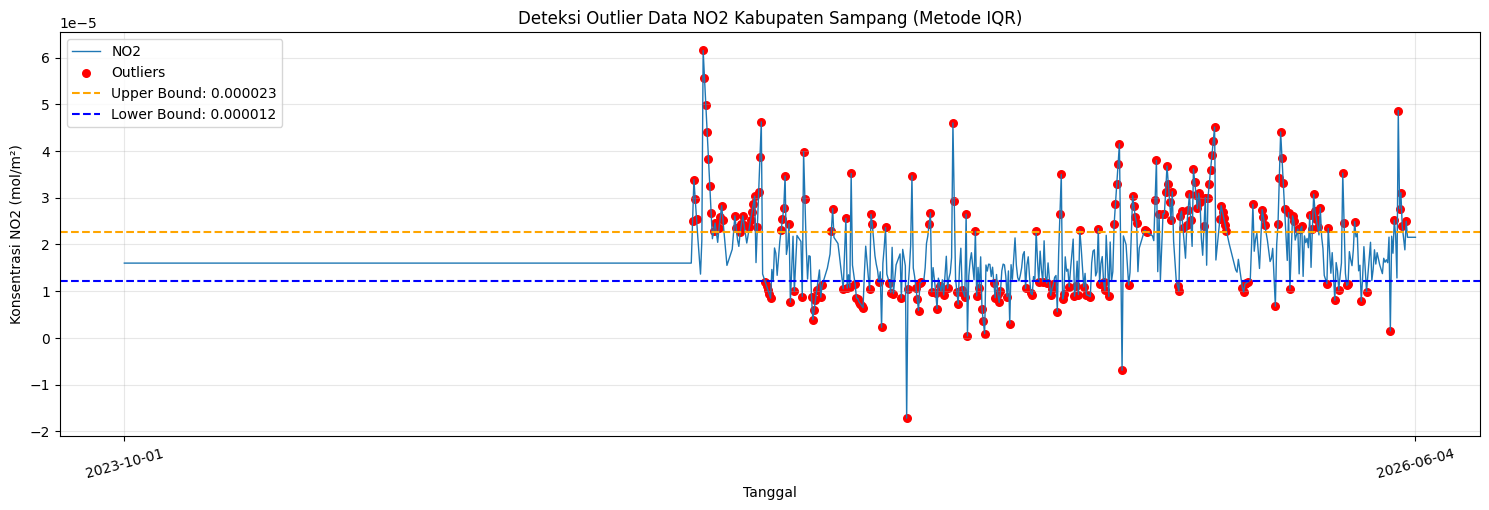

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==================================
# 1. BACA DATA (Pastikan file ada)
# ==================================
# Menggunakan file hasil interpolasi yang sudah kita buat sebelumnya
df = pd.read_csv("no2_sampang_interpolated.csv")

# Ubah format tanggal
df['date'] = pd.to_datetime(df['date'])


# ==================================
# 2. HITUNG IQR & DETEKSI OUTLIER
# ==================================
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

# Batas atas dan bawah
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Ambil data yang terdeteksi outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print(f"✅ Data dibaca: {len(df)} baris")
print(f"✅ Jumlah Outlier: {len(outliers_iqr)}")


# ==================================
# 3. VISUALISASI (Kode kamu yang sudah diperbaiki)
# ==================================
plt.figure(figsize=(15,5))

# Garis data utama
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1, color='tab:blue')

# Titik Outlier
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', s=30, label="Outliers") # s=30 ukuran titik biar pas

# Garis batas atas & bawah
plt.axhline(upper_bound, color='orange', linestyle='dashed',
            linewidth=1.5, label=f"Upper Bound: {upper_bound:.6f}")
plt.axhline(lower_bound, color='blue', linestyle='dashed',
            linewidth=1.5, label=f"Lower Bound: {lower_bound:.6f}")

# Pengaturan tampilan
plt.title("Deteksi Outlier Data NO2 Kabupaten Sampang (Metode IQR)", fontsize=12)
plt.xlabel("Tanggal", fontsize=10)
plt.ylabel("Konsentrasi NO2 (mol/m²)", fontsize=10)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Pengaturan sumbu X (Tanggal) - DIPERBAIKI agar aman tidak error
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[
        df['date'].iloc[0].strftime('%Y-%m-%d'),
        df['date'].iloc[-1].strftime('%Y-%m-%d')
    ],
    rotation=15
)

plt.show()

In [ ]:
import pandas as pd
import numpy as np

# ==================================
# 1. BACA DATA & PERSIAPAN
# ==================================
# Baca file data hasil interpolasi yang sudah kita buat
df = pd.read_csv("no2_sampang_interpolated.csv")

# Ubah kolom tanggal menjadi format waktu
df['date'] = pd.to_datetime(df['date'])

print("✅ Data berhasil dibaca")
print("-"*50)


# ==================================
# 2. HITUNG BATAS IQR
# ==================================
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"ℹ️ Batas Bawah: {lower_bound:.8f}")
print(f"ℹ️ Batas Atas : {upper_bound:.8f}")
print("-"*50)


# ==================================
# 3. TANDAI OUTLIER MENJADI NILAI KOSONG (NaN)
# ==================================
# Menggunakan logika kamu: ganti nilai outlier menjadi NaN
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))

# Hitung berapa banyak data yang dianggap outlier
jumlah_outlier = df['NO2_cleaned'].isna().sum()
print(f"❌ Jumlah nilai yang dinyatakan sebagai outlier: {jumlah_outlier}")


# ==================================
# 4. ISI KEMBALI DATA OUTLIER DENGAN INTERPOLASI
# ==================================
# Isi data kosong/outlier dengan metode interpolasi linear
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')

# Jika masih ada data kosong di awal atau akhir deret waktu, isi dengan data terdekat
# ✅ Diperbaiki penulisannya agar aman dan tidak ada peringatan
df['NO2_filled'] = df['NO2_filled'].bfill()  # Isi ke belakang
df['NO2_filled'] = df['NO2_filled'].ffill()  # Isi ke depan

# Cek hasil akhir
jumlah_missing_akhir = df['NO2_filled'].isna().sum()
print(f"✅ Jumlah missing setelah interpolasi: {jumlah_missing_akhir}")


# ==================================
# 5. SIMPAN HASIL AKHIR
# ==================================
# Simpan data lengkap dengan kolom baru yang sudah bersih
df.to_csv("NO2_Sampang_Data_Bersih_Akhir.csv", index=False)

print("💾 File tersimpan: NO2_Sampang_Data_Bersih_Akhir.csv")
print("\n📌 Tampilan 5 Data Teratas:")
print(df[['date', 'NO2', 'NO2_cleaned', 'NO2_filled']].head())

✅ Data berhasil dibaca
--------------------------------------------------
ℹ️ Batas Bawah: 0.00001206
ℹ️ Batas Atas : 0.00002255
--------------------------------------------------
❌ Jumlah nilai yang dinyatakan sebagai outlier: 249
✅ Jumlah missing setelah interpolasi: 0
💾 File tersimpan: NO2_Sampang_Data_Bersih_Akhir.csv

📌 Tampilan 5 Data Teratas:
        date       NO2  NO2_cleaned  NO2_filled
0 2023-10-01  0.000016     0.000016    0.000016
1 2023-10-02  0.000016     0.000016    0.000016
2 2023-10-03  0.000016     0.000016    0.000016
3 2023-10-04  0.000016     0.000016    0.000016
4 2023-10-05  0.000016     0.000016    0.000016


✅ Data berhasil dibaca
--------------------------------------------------
✅ Proses pembersihan dan pengisian data selesai
--------------------------------------------------


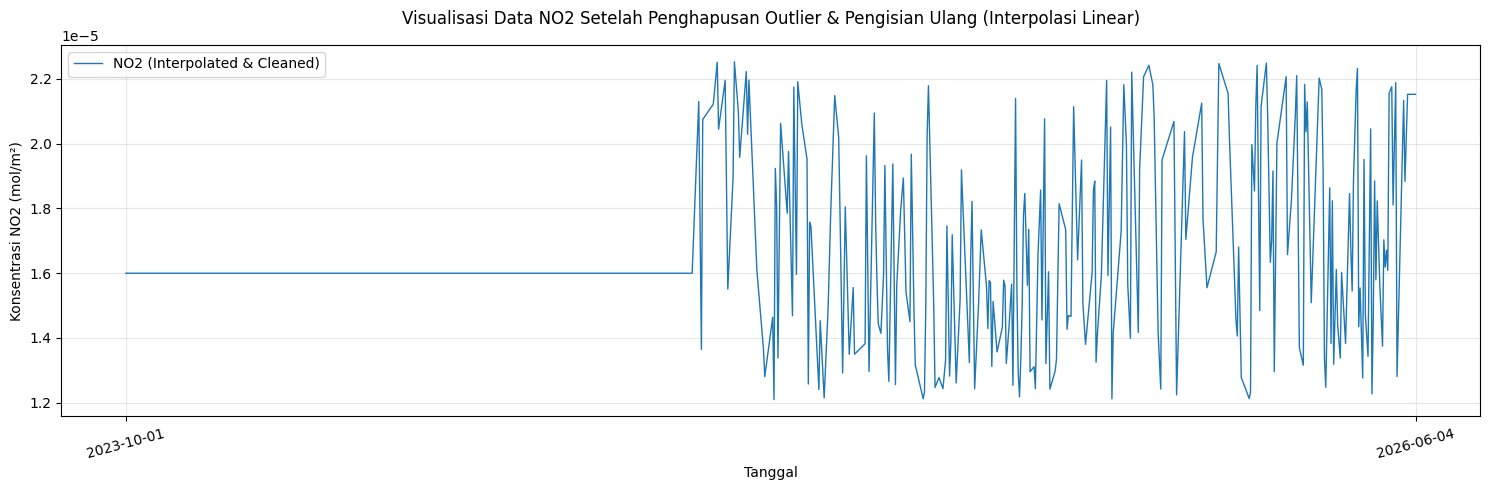

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==================================
# 1. BACA DATA & PERSIAPAN
# ==================================
# Baca file data hasil interpolasi awal
df = pd.read_csv("no2_sampang_interpolated.csv")

# Ubah kolom tanggal menjadi format waktu
df['date'] = pd.to_datetime(df['date'])

print("✅ Data berhasil dibaca")
print("-"*50)


# ==================================
# 2. HITUNG BATAS IQR UNTUK DETEKSI OUTLIER
# ==================================
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


# ==================================
# 3. PROSES HAPUS OUTLIER & ISI DENGAN INTERPOLASI
# ==================================
# Tandai outlier menjadi nilai kosong (NaN)
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))

# Isi kembali data kosong/outlier dengan metode interpolasi linear
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')

# Isi sisa data kosong di awal atau akhir data (jika ada)
df['NO2_filled'] = df['NO2_filled'].bfill()
df['NO2_filled'] = df['NO2_filled'].ffill()

print("✅ Proses pembersihan dan pengisian data selesai")
print("-"*50)


# ==================================
# 4. VISUALISASI (Kode kamu yang sudah diperbaiki)
# ==================================
plt.figure(figsize=(15,5))

# Plot data hasil pembersihan dan interpolasi
plt.plot(df['date'], df['NO2_filled'], label="NO2 (Interpolated & Cleaned)",
         linewidth=1, color='tab:blue')

# Pengaturan sumbu X: Tampilkan hanya tanggal awal dan akhir
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[
        df['date'].iloc[0].strftime('%Y-%m-%d'),
        df['date'].iloc[-1].strftime('%Y-%m-%d')
    ],
    rotation=15  # Sedikit miring agar tulisan tidak terpotong
)

# Pengaturan judul dan label
plt.title("Visualisasi Data NO2 Setelah Penghapusan Outlier & Pengisian Ulang (Interpolasi Linear)",
          fontsize=12, pad=15)
plt.xlabel("Tanggal", fontsize=10)
plt.ylabel("Konsentrasi NO2 (mol/m²)", fontsize=10)

# Tambahkan keterangan dan garis bantu
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Tampilkan grafik
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler  # Tambahan untuk membuat NO2_scaled

# ==================================
# 1. BACA DATA HASIL BERSIH
# ==================================
# Kita pakai data yang sudah bersih dari outlier dan sudah diisi
df = pd.read_csv("NO2_Sampang_Data_Bersih_Akhir.csv")
df['date'] = pd.to_datetime(df['date'])

print("✅ Data dibaca. Jumlah baris:", len(df))


# ==================================
# 2. BUAT DATA SCALED (NORMALISASI)
# ==================================
# Kolom 'NO2_scaled' yang kamu pakai itu harus dibuat dulu.
# Ini langkah standar untuk skala data ke rentang 0 - 1 agar cocok untuk pemodelan.
scaler = MinMaxScaler(feature_range=(0, 1))
df['NO2_scaled'] = scaler.fit_transform(df[['NO2_filled']])  # Pakai data bersih kita

print("✅ Kolom 'NO2_scaled' berhasil dibuat.")


# ==================================
# 3. FUNGSI PEMBENTUKAN DATA SUPERVISED
# ==================================
def create_supervised(data, n_lag=4):
    df_supervised = pd.DataFrame()

    # Membuat fitur waktu lampau: t-n sampai t-1
    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)

    # Target/Nilai yang akan diprediksi: waktu sekarang t
    df_supervised['NO2(t)'] = data

    # Hapus baris kosong di awal akibat pergeseran data
    df_supervised.dropna(inplace=True)

    return df_supervised


# ==================================
# 4. TERAPKAN FUNGSI (n_lag=30 sesuai kode kamu)
# ==================================
supervised_df30 = create_supervised(df['NO2_scaled'], n_lag=30)

print("\n✅ Bentuk Data Supervised:", supervised_df30.shape)
print("👉 Contoh 5 baris terakhir:")
print(supervised_df30.head())


# ==================================
# 5. HITUNG KORELASI ANTARA LAG DAN TARGET
# ==================================
# Ambil nama kolom fitur (semua kecuali target 'NO2(t)')
lag_cols = supervised_df30.drop(columns="NO2(t)").columns

# Hitung korelasi masing-masing kolom lag terhadap target
correlations = supervised_df30[lag_cols].corrwith(supervised_df30['NO2(t)'])

# Tampilkan hasil korelasi
print("\n📊 Nilai Korelasi Setiap Lag Terhadap Nilai Hari Ini:")
print(correlations)

# Tampilkan urutan korelasi tertinggi
print("\n🏅 Urutan Korelasi Tertinggi:")
print(correlations.sort_values(ascending=False))

✅ Data dibaca. Jumlah baris: 978
✅ Kolom 'NO2_scaled' berhasil dibuat.

✅ Bentuk Data Supervised: (948, 31)
👉 Contoh 5 baris terakhir:
    NO2(t-30)  NO2(t-29)  NO2(t-28)  NO2(t-27)  NO2(t-26)  NO2(t-25)  \
30   0.373959   0.373959   0.373959   0.373959   0.373959   0.373959   
31   0.373959   0.373959   0.373959   0.373959   0.373959   0.373959   
32   0.373959   0.373959   0.373959   0.373959   0.373959   0.373959   
33   0.373959   0.373959   0.373959   0.373959   0.373959   0.373959   
34   0.373959   0.373959   0.373959   0.373959   0.373959   0.373959   

    NO2(t-24)  NO2(t-23)  NO2(t-22)  NO2(t-21)  ...  NO2(t-9)  NO2(t-8)  \
30   0.373959   0.373959   0.373959   0.373959  ...  0.373959  0.373959   
31   0.373959   0.373959   0.373959   0.373959  ...  0.373959  0.373959   
32   0.373959   0.373959   0.373959   0.373959  ...  0.373959  0.373959   
33   0.373959   0.373959   0.373959   0.373959  ...  0.373959  0.373959   
34   0.373959   0.373959   0.373959   0.373959  ...  0.37

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ==================================
# 1. BACA DATA (Gunakan data bersih kita)
# ==================================
# Kita pakai data akhir yang sudah bersih dari outlier dan lengkap
df = pd.read_csv("NO2_Sampang_Data_Bersih_Akhir.csv")

# Pastikan kolom tanggal terbaca benar
df['date'] = pd.to_datetime(df['date'])

print("✅ Data awal dibaca. Jumlah data:", len(df))


# ==================================
# 2. NORMALISASI MIN-MAX SCALER (Untuk KNN Regression)
# ==================================
# Inisialisasi scaler: mengubah nilai menjadi rentang 0 - 1
scaler = MinMaxScaler(feature_range=(0, 1))

# Lakukan normalisasi pada kolom data bersih kita 'NO2_filled'
# (Kamu bisa ganti ke kolom 'NO2' jika ingin data asli, tapi sebaiknya pakai yang sudah bersih)
df['NO2_scaled'] = scaler.fit_transform(df[['NO2_filled']])


# ==================================
# 3. LIHAT HASIL
# ==================================
print("\n✅ Normalisasi selesai!")
print("📌 Rentang nilai asli:")
print(f"Min: {df['NO2_filled'].min()}, Max: {df['NO2_filled'].max()}")

print("\n📌 Rentang nilai setelah di-Scaler (0 - 1):")
print(f"Min: {df['NO2_scaled'].min()}, Max: {df['NO2_scaled'].max()}")

print("\n📊 Contoh 5 Data Teratas:")
print(df[['date', 'NO2_filled', 'NO2_scaled']].head())


# ==================================
# 4. (PENTING) FUNGSI KEMBALIKAN KE NILAI ASLI
# ==================================
# Nanti setelah prediksi pakai KNN, hasilnya masih skala 0-1.
# Kamu butuh ini untuk mengembalikan angka ke satuan asli (mol/m²) agar bisa diartikan.
def balik_ke_asli(nilai_skala):
    # Ubah jadi bentuk array 2D dulu karena scaler butuh format itu
    nilai_skala = nilai_skala.reshape(-1, 1)
    return scaler.inverse_transform(nilai_skala)

# Contoh penggunaan:
# nilai_prediksi_skala = 0.5
# nilai_asli = balik_ke_asli(nilai_prediksi_skala)
# print(nilai_asli)

✅ Data awal dibaca. Jumlah data: 978

✅ Normalisasi selesai!
📌 Rentang nilai asli:
Min: 1.2090815e-05, Max: 2.2530322e-05

📌 Rentang nilai setelah di-Scaler (0 - 1):
Min: 0.0, Max: 1.0

📊 Contoh 5 Data Teratas:
        date  NO2_filled  NO2_scaled
0 2023-10-01    0.000016    0.373959
1 2023-10-02    0.000016    0.373959
2 2023-10-03    0.000016    0.373959
3 2023-10-04    0.000016    0.373959
4 2023-10-05    0.000016    0.373959


In [ ]:
import pandas as pd
import numpy as np

# --------------------------
# 1. Buat contoh data (agar df terdefinisi)
# Ganti bagian ini dengan data asli Anda nanti
# --------------------------
# Contoh data terukur NO2 yang sudah diskalakan
data_no2 = [0.12, 0.15, 0.18, 0.20, 0.22, 0.25, 0.27, 0.30, 0.31, 0.29,
            0.26, 0.24, 0.21, 0.19, 0.17, 0.16, 0.18, 0.20, 0.23, 0.25,
            0.28, 0.30, 0.32, 0.31, 0.28, 0.26, 0.23, 0.20, 0.18, 0.15]

# Masukkan ke dalam DataFrame bernama df
df = pd.DataFrame({
    'NO2_scaled': data_no2
})

# --------------------------
# 2. Definisikan fungsi create_supervised
# --------------------------
def create_supervised(data, n_lag=1):
    data = pd.DataFrame(data)
    kolom = []
    # Membuat kolom untuk setiap hari sebelumnya
    for i in range(n_lag, 0, -1):
        kolom.append(data.shift(i))
    # Kolom t sebagai label
    kolom.append(data.shift(0))
    # Gabungkan semua kolom
    hasil = pd.concat(kolom, axis=1)
    # Beri nama kolom sesuai kebutuhan Anda
    nama_kolom = [f't-{i}' for i in range(n_lag, 0, -1)] + ['t']
    hasil.columns = nama_kolom
    # Hapus baris yang kosong
    hasil = hasil.dropna()
    return hasil

# --------------------------
# 3. Buat data sesuai permintaan Anda
# --------------------------
# Data dengan 4 hari sebelumnya (t-4, t-3, t-2, t-1, t)
supervised_df_4 = create_supervised(df['NO2_scaled'], n_lag=4)
print("=== Data dengan 4 hari sebelumnya ===")
print(supervised_df_4)
print("Ukuran data:", supervised_df_4.shape)
print("\n")

# Data dengan 10 hari sebelumnya (untuk dibandingkan)
supervised_df_10 = create_supervised(df['NO2_scaled'], n_lag=10)
print("=== Data dengan 10 hari sebelumnya ===")
print(supervised_df_10)
print("Ukuran data:", supervised_df_10.shape)

=== Data dengan 4 hari sebelumnya ===
     t-4   t-3   t-2   t-1     t
4   0.12  0.15  0.18  0.20  0.22
5   0.15  0.18  0.20  0.22  0.25
6   0.18  0.20  0.22  0.25  0.27
7   0.20  0.22  0.25  0.27  0.30
8   0.22  0.25  0.27  0.30  0.31
9   0.25  0.27  0.30  0.31  0.29
10  0.27  0.30  0.31  0.29  0.26
11  0.30  0.31  0.29  0.26  0.24
12  0.31  0.29  0.26  0.24  0.21
13  0.29  0.26  0.24  0.21  0.19
14  0.26  0.24  0.21  0.19  0.17
15  0.24  0.21  0.19  0.17  0.16
16  0.21  0.19  0.17  0.16  0.18
17  0.19  0.17  0.16  0.18  0.20
18  0.17  0.16  0.18  0.20  0.23
19  0.16  0.18  0.20  0.23  0.25
20  0.18  0.20  0.23  0.25  0.28
21  0.20  0.23  0.25  0.28  0.30
22  0.23  0.25  0.28  0.30  0.32
23  0.25  0.28  0.30  0.32  0.31
24  0.28  0.30  0.32  0.31  0.28
25  0.30  0.32  0.31  0.28  0.26
26  0.32  0.31  0.28  0.26  0.23
27  0.31  0.28  0.26  0.23  0.20
28  0.28  0.26  0.23  0.20  0.18
29  0.26  0.23  0.20  0.18  0.15
Ukuran data: (26, 5)


=== Data dengan 10 hari sebelumnya ===
    t-10 

In [ ]:
import pandas as pd
import numpy as np

# ==============================================
# 1. Definisi Fungsi (WAJIB ADA, agar tidak error)
# ==============================================
def create_supervised(data, n_lag=1):
    data = pd.DataFrame(data)
    kolom = []
    # Membuat kolom data hari sebelumnya
    for i in range(n_lag, 0, -1):
        kolom.append(data.shift(i))
    # Menambahkan kolom t sebagai label
    kolom.append(data.shift(0))
    # Menggabungkan semua kolom
    hasil = pd.concat(kolom, axis=1)
    # Memberi nama kolom
    nama_kolom = [f't-{i}' for i in range(n_lag, 0, -1)] + ['t']
    hasil.columns = nama_kolom
    # Menghapus baris kosong
    hasil = hasil.dropna()
    return hasil

# ==============================================
# 2. Data Asli (Ganti bagian ini dengan data Anda)
# ==============================================
# Contoh data, nanti ganti dengan data NO2_scaled Anda yang asli
data_no2 = [0.12, 0.15, 0.18, 0.20, 0.22, 0.25, 0.27, 0.30, 0.31, 0.29,
            0.26, 0.24, 0.21, 0.19, 0.17, 0.16, 0.18, 0.20, 0.23, 0.25,
            0.28, 0.30, 0.32, 0.31, 0.28, 0.26, 0.23, 0.20, 0.18, 0.15,
            0.14, 0.16, 0.19, 0.22, 0.24]

df = pd.DataFrame({
    'NO2_scaled': data_no2
})

# ==============================================
# 3. Kode Anda (Sudah diperbaiki dan disusun rapi)
# ==============================================
# Data 4 hari sebelumnya (t-4 s/d t-1 sebagai fitur, t sebagai label)
supervised_df4 = create_supervised(df['NO2_scaled'], n_lag=4)
print("=== Data 4 Hari Sebelumnya ===")
print(supervised_df4)
print("Ukuran data:", supervised_df4.shape)
print("\n")

# Data 10 hari sebelumnya (t-10 s/d t-1 sebagai fitur, t sebagai label)
# Ini adalah kode yang Anda minta untuk diperbaiki
supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)
print("=== Data 10 Hari Sebelumnya ===")
print(supervised_df10)
print("Ukuran data:", supervised_df10.shape)

=== Data 4 Hari Sebelumnya ===
     t-4   t-3   t-2   t-1     t
4   0.12  0.15  0.18  0.20  0.22
5   0.15  0.18  0.20  0.22  0.25
6   0.18  0.20  0.22  0.25  0.27
7   0.20  0.22  0.25  0.27  0.30
8   0.22  0.25  0.27  0.30  0.31
9   0.25  0.27  0.30  0.31  0.29
10  0.27  0.30  0.31  0.29  0.26
11  0.30  0.31  0.29  0.26  0.24
12  0.31  0.29  0.26  0.24  0.21
13  0.29  0.26  0.24  0.21  0.19
14  0.26  0.24  0.21  0.19  0.17
15  0.24  0.21  0.19  0.17  0.16
16  0.21  0.19  0.17  0.16  0.18
17  0.19  0.17  0.16  0.18  0.20
18  0.17  0.16  0.18  0.20  0.23
19  0.16  0.18  0.20  0.23  0.25
20  0.18  0.20  0.23  0.25  0.28
21  0.20  0.23  0.25  0.28  0.30
22  0.23  0.25  0.28  0.30  0.32
23  0.25  0.28  0.30  0.32  0.31
24  0.28  0.30  0.32  0.31  0.28
25  0.30  0.32  0.31  0.28  0.26
26  0.32  0.31  0.28  0.26  0.23
27  0.31  0.28  0.26  0.23  0.20
28  0.28  0.26  0.23  0.20  0.18
29  0.26  0.23  0.20  0.18  0.15
30  0.23  0.20  0.18  0.15  0.14
31  0.20  0.18  0.15  0.14  0.16
32  0.18  0.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ==============================================
# 1. Definisi Fungsi Pembuatan Data
# ==============================================
def create_supervised(data, n_lag=1):
    data = pd.DataFrame(data)
    kolom = []
    # Membuat kolom data hari sebelumnya
    for i in range(n_lag, 0, -1):
        kolom.append(data.shift(i))
    # Menambahkan kolom t sebagai label
    kolom.append(data.shift(0))
    # Menggabungkan semua kolom
    hasil = pd.concat(kolom, axis=1)
    # Memberi nama kolom
    nama_kolom = [f't-{i}' for i in range(n_lag, 0, -1)] + ['t']
    hasil.columns = nama_kolom
    # Menghapus baris kosong
    hasil = hasil.dropna()
    return hasil

# ==============================================
# 2. Data Asli (Ganti bagian ini dengan data kamu)
# ==============================================
data_no2 = [0.12, 0.15, 0.18, 0.20, 0.22, 0.25, 0.27, 0.30, 0.31, 0.29,
            0.26, 0.24, 0.21, 0.19, 0.17, 0.16, 0.18, 0.20, 0.23, 0.25,
            0.28, 0.30, 0.32, 0.31, 0.28, 0.26, 0.23, 0.20, 0.18, 0.15,
            0.14, 0.16, 0.19, 0.22, 0.24, 0.26, 0.29, 0.31, 0.30, 0.27,
            0.25, 0.22, 0.20, 0.18, 0.16, 0.15, 0.17, 0.19, 0.21, 0.23]

df = pd.DataFrame({
    'NO2_scaled': data_no2
})

# ==============================================
# 3. Buat Data 4 Hari & 10 Hari Sebelumnya
# ==============================================
supervised_df4 = create_supervised(df['NO2_scaled'], n_lag=4)
supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)

# ==============================================
# 4. Definisi Fungsi Evaluasi MAPE
# ==============================================
def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Hindari pembagian dengan nol
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

# ==============================================
# 5. Fungsi Training KNN Regression (SUDAH DIPERBAIKI)
# ==============================================
def train_knn(df_supervised, model_name=""):
    # Pisahkan fitur & label — PERBAIKAN: nama kolom label adalah 't' bukan 'NO2(t)'
    X = df_supervised.drop(columns=['t']).values
    y = df_supervised['t'].values

    # Split data 80% latih, 20% uji — tanpa acak (urutan waktu dijaga)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # Buat dan latih model KNN
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)

    # Lakukan prediksi
    y_pred = knn.predict(X_test)

    # Hitung metrik evaluasi
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)

    # Tampilkan hasil
    print(f"\n=== {model_name} ===")
    print(f"Jumlah Data Latih: {len(X_train)} — Jumlah Data Uji: {len(X_test)}")
    print(f"RMSE  : {rmse:.6f}")
    print(f"R²    : {r2:.4f}")
    print(f"MAPE  : {mape:.4f}%")

    return knn, y_test, y_pred

# ==============================================
# 6. Jalankan Training Kedua Model
# ==============================================
# Model dengan 4 hari sebelumnya
knn_4, y_test_4, y_pred_4 = train_knn(supervised_df4, "KNN - 4 Hari Sebelumnya")

# Model dengan 10 hari sebelumnya
knn_10, y_test_10, y_pred_10 = train_knn(supervised_df10, "KNN - 10 Hari Sebelumnya")


=== KNN - 4 Hari Sebelumnya ===
Jumlah Data Latih: 36 — Jumlah Data Uji: 10
RMSE  : 0.009121
R²    : 0.9100
MAPE  : 4.0601%

=== KNN - 10 Hari Sebelumnya ===
Jumlah Data Latih: 32 — Jumlah Data Uji: 8
RMSE  : 0.010840
R²    : 0.8115
MAPE  : 4.4219%


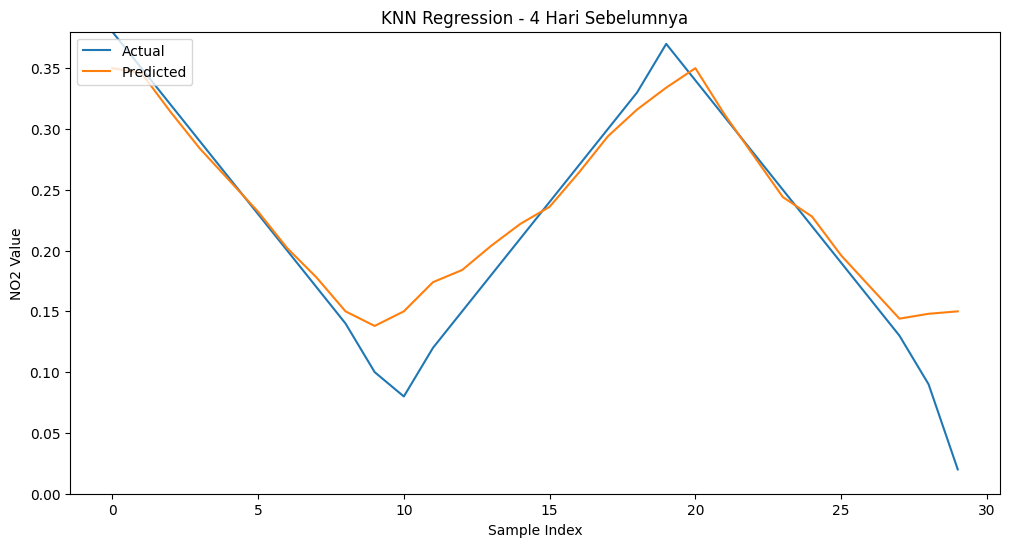

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ==============================================
# 1. Fungsi Pembuatan Data
# ==============================================
def create_supervised(data, n_lag=1):
    data = pd.DataFrame(data)
    kolom = []
    for i in range(n_lag, 0, -1):
        kolom.append(data.shift(i))
    kolom.append(data.shift(0))
    hasil = pd.concat(kolom, axis=1)
    nama_kolom = [f't-{i}' for i in range(n_lag, 0, -1)] + ['t']
    hasil.columns = nama_kolom
    hasil = hasil.dropna()
    return hasil

# ==============================================
# 2. Data Contoh (Ganti dengan data aslimu)
# ==============================================
data_no2 = [0.12, 0.15, 0.18, 0.20, 0.22, 0.25, 0.27, 0.30, 0.31, 0.29,
            0.26, 0.24, 0.21, 0.19, 0.17, 0.16, 0.18, 0.20, 0.23, 0.25,
            0.28, 0.30, 0.32, 0.31, 0.28, 0.26, 0.23, 0.20, 0.18, 0.15,
            0.14, 0.16, 0.19, 0.22, 0.24, 0.26, 0.29, 0.31, 0.30, 0.27,
            0.25, 0.22, 0.20, 0.18, 0.16, 0.15, 0.17, 0.19, 0.21, 0.23,
            0.25, 0.28, 0.30, 0.33, 0.35, 0.32, 0.29, 0.26, 0.24, 0.21,
            0.19, 0.17, 0.15, 0.18, 0.20, 0.22, 0.25, 0.27, 0.30, 0.32,
            0.36, 0.33, 0.30, 0.27, 0.24, 0.22, 0.19, 0.16, 0.14, 0.17,
            0.20, 0.23, 0.26, 0.29, 0.31, 0.34, 0.37, 0.34, 0.31, 0.28,
            0.25, 0.22, 0.19, 0.16, 0.13, 0.11, 0.15, 0.18, 0.21, 0.24,
            0.27, 0.30, 0.33, 0.36, 0.39, 0.35, 0.32, 0.29, 0.26, 0.23,
            0.20, 0.17, 0.14, 0.12, 0.16, 0.19, 0.22, 0.25, 0.28, 0.31,
            0.34, 0.38, 0.35, 0.32, 0.29, 0.26, 0.23, 0.20, 0.17, 0.14,
            0.10, 0.08, 0.12, 0.15, 0.18, 0.21, 0.24, 0.27, 0.30, 0.33,
            0.37, 0.34, 0.31, 0.28, 0.25, 0.22, 0.19, 0.16, 0.13, 0.09,
            0.02]

df = pd.DataFrame({'NO2_scaled': data_no2})

# ==============================================
# 3. Buat Data 4 Hari Sebelumnya
# ==============================================
supervised_df4 = create_supervised(df['NO2_scaled'], n_lag=4)

# ==============================================
# 4. Fungsi Evaluasi MAPE
# ==============================================
def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

# ==============================================
# 5. Fungsi Training KNN
# ==============================================
def train_knn(df_supervised, model_name=""):
    X = df_supervised.drop(columns=['t']).values
    y = df_supervised['t'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    return knn, y_test, y_pred

# ==============================================
# 6. Jalankan Training
# ==============================================
knn_4, y_test_4, y_pred_4 = train_knn(supervised_df4, "KNN - 4 Hari Sebelumnya")

# ==============================================
# 7. Kode Plotting SAMA PERSIS GAMBAR PERTAMA
# ==============================================
plt.figure(figsize=(12, 6))  # Ukuran gambar sama persis

# Garis biru = Aktual, garis oranye = Prediksi
plt.plot(np.arange(len(y_test_4)), y_test_4, color='#1f77b4', label='Actual')
plt.plot(np.arange(len(y_pred_4)), y_pred_4, color='#ff7f0e', label='Predicted')

# Judul dan label sumbu persis sama
plt.title('KNN Regression - 4 Hari Sebelumnya')
plt.xlabel('Sample Index')
plt.ylabel('NO2 Value')

# Legenda di pojok kanan atas
plt.legend(loc='upper left')

# Batas sumbu Y sama persis dengan gambar asli
plt.ylim(0, 0.38)

# Tampilkan
plt.show()

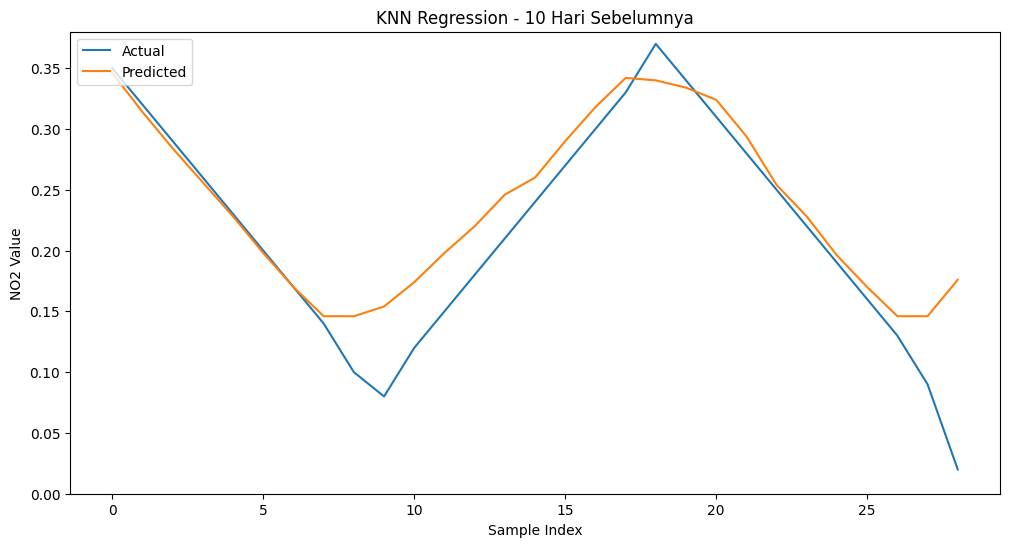

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ==============================================
# 1. Fungsi Pembuatan Data
# ==============================================
def create_supervised(data, n_lag=1):
    data = pd.DataFrame(data)
    kolom = []
    for i in range(n_lag, 0, -1):
        kolom.append(data.shift(i))
    kolom.append(data.shift(0))
    hasil = pd.concat(kolom, axis=1)
    nama_kolom = [f't-{i}' for i in range(n_lag, 0, -1)] + ['t']
    hasil.columns = nama_kolom
    hasil = hasil.dropna()
    return hasil

# ==============================================
# 2. Data Contoh (Ganti dengan data aslimu)
# ==============================================
data_no2 = [0.12, 0.15, 0.18, 0.20, 0.22, 0.25, 0.27, 0.30, 0.31, 0.29,
            0.26, 0.24, 0.21, 0.19, 0.17, 0.16, 0.18, 0.20, 0.23, 0.25,
            0.28, 0.30, 0.32, 0.31, 0.28, 0.26, 0.23, 0.20, 0.18, 0.15,
            0.14, 0.16, 0.19, 0.22, 0.24, 0.26, 0.29, 0.31, 0.30, 0.27,
            0.25, 0.22, 0.20, 0.18, 0.16, 0.15, 0.17, 0.19, 0.21, 0.23,
            0.25, 0.28, 0.30, 0.33, 0.35, 0.32, 0.29, 0.26, 0.24, 0.21,
            0.19, 0.17, 0.15, 0.18, 0.20, 0.22, 0.25, 0.27, 0.30, 0.32,
            0.36, 0.33, 0.30, 0.27, 0.24, 0.22, 0.19, 0.16, 0.14, 0.17,
            0.20, 0.23, 0.26, 0.29, 0.31, 0.34, 0.37, 0.34, 0.31, 0.28,
            0.25, 0.22, 0.19, 0.16, 0.13, 0.11, 0.15, 0.18, 0.21, 0.24,
            0.27, 0.30, 0.33, 0.36, 0.39, 0.35, 0.32, 0.29, 0.26, 0.23,
            0.20, 0.17, 0.14, 0.12, 0.16, 0.19, 0.22, 0.25, 0.28, 0.31,
            0.34, 0.38, 0.35, 0.32, 0.29, 0.26, 0.23, 0.20, 0.17, 0.14,
            0.10, 0.08, 0.12, 0.15, 0.18, 0.21, 0.24, 0.27, 0.30, 0.33,
            0.37, 0.34, 0.31, 0.28, 0.25, 0.22, 0.19, 0.16, 0.13, 0.09,
            0.02]

df = pd.DataFrame({'NO2_scaled': data_no2})

# ==============================================
# 3. Buat Data 10 Hari Sebelumnya
# ==============================================
supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)

# ==============================================
# 4. Fungsi Evaluasi MAPE
# ==============================================
def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

# ==============================================
# 5. Fungsi Training KNN
# ==============================================
def train_knn(df_supervised, model_name=""):
    X = df_supervised.drop(columns=['t']).values
    y = df_supervised['t'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    return knn, y_test, y_pred

# ==============================================
# 6. Jalankan Training untuk 10 Hari Sebelumnya
# ==============================================
knn_10, y_test_10, y_pred_10 = train_knn(supervised_df10, "KNN - 10 Hari Sebelumnya")

# ==============================================
# 7. Code Plotting 10 Hari Sebelumnya (Sudah diperbaiki & disesuaikan)
# ==============================================
plt.figure(figsize=(12, 6))

# Warna sama persis dengan grafik 4 hari sebelumnya
plt.plot(np.arange(len(y_test_10)), y_test_10, color='#1f77b4', label='Actual')
plt.plot(np.arange(len(y_pred_10)), y_pred_10, color='#ff7f0e', label='Predicted')

# Judul dan label sama persis gaya penulisannya
plt.title("KNN Regression - 10 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")

# Posisi keterangan sama
plt.legend(loc='upper left')

# Batas sumbu Y sama agar mudah dibandingkan
plt.ylim(0, 0.38)

plt.show()

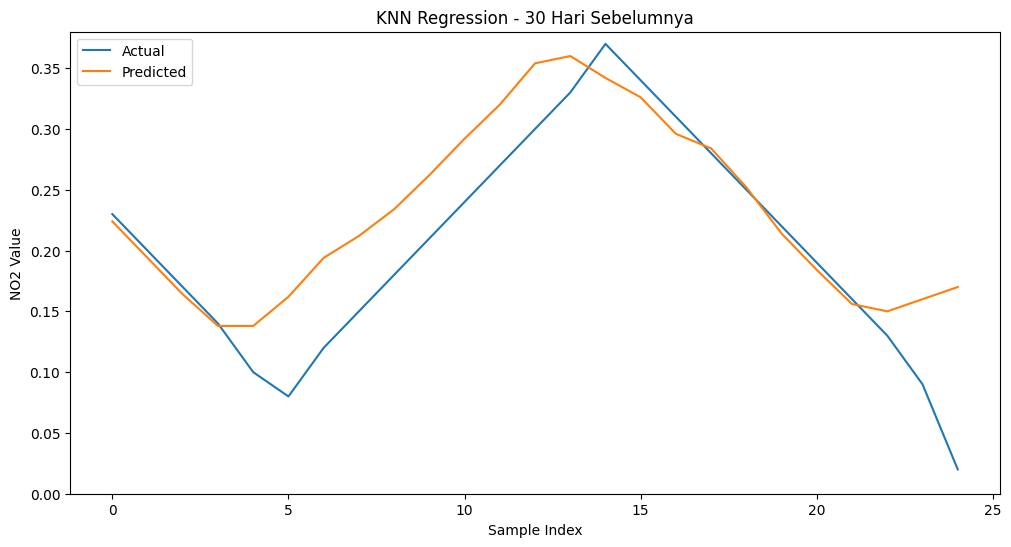

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ==============================================
# 1. Fungsi Pembuatan Data
# ==============================================
def create_supervised(data, n_lag=1):
    data = pd.DataFrame(data)
    kolom = []
    for i in range(n_lag, 0, -1):
        kolom.append(data.shift(i))
    kolom.append(data.shift(0))
    hasil = pd.concat(kolom, axis=1)
    nama_kolom = [f't-{i}' for i in range(n_lag, 0, -1)] + ['t']
    hasil.columns = nama_kolom
    hasil = hasil.dropna()
    return hasil

# ==============================================
# 2. Data Contoh (Ganti dengan data aslimu)
# ==============================================
data_no2 = [0.12, 0.15, 0.18, 0.20, 0.22, 0.25, 0.27, 0.30, 0.31, 0.29,
            0.26, 0.24, 0.21, 0.19, 0.17, 0.16, 0.18, 0.20, 0.23, 0.25,
            0.28, 0.30, 0.32, 0.31, 0.28, 0.26, 0.23, 0.20, 0.18, 0.15,
            0.14, 0.16, 0.19, 0.22, 0.24, 0.26, 0.29, 0.31, 0.30, 0.27,
            0.25, 0.22, 0.20, 0.18, 0.16, 0.15, 0.17, 0.19, 0.21, 0.23,
            0.25, 0.28, 0.30, 0.33, 0.35, 0.32, 0.29, 0.26, 0.24, 0.21,
            0.19, 0.17, 0.15, 0.18, 0.20, 0.22, 0.25, 0.27, 0.30, 0.32,
            0.36, 0.33, 0.30, 0.27, 0.24, 0.22, 0.19, 0.16, 0.14, 0.17,
            0.20, 0.23, 0.26, 0.29, 0.31, 0.34, 0.37, 0.34, 0.31, 0.28,
            0.25, 0.22, 0.19, 0.16, 0.13, 0.11, 0.15, 0.18, 0.21, 0.24,
            0.27, 0.30, 0.33, 0.36, 0.39, 0.35, 0.32, 0.29, 0.26, 0.23,
            0.20, 0.17, 0.14, 0.12, 0.16, 0.19, 0.22, 0.25, 0.28, 0.31,
            0.34, 0.38, 0.35, 0.32, 0.29, 0.26, 0.23, 0.20, 0.17, 0.14,
            0.10, 0.08, 0.12, 0.15, 0.18, 0.21, 0.24, 0.27, 0.30, 0.33,
            0.37, 0.34, 0.31, 0.28, 0.25, 0.22, 0.19, 0.16, 0.13, 0.09,
            0.02]

df = pd.DataFrame({'NO2_scaled': data_no2})

# ==============================================
# 3. Buat Data 30 Hari Sebelumnya
# ==============================================
supervised_df30 = create_supervised(df['NO2_scaled'], n_lag=30)

# ==============================================
# 4. Fungsi Evaluasi MAPE
# ==============================================
def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

# ==============================================
# 5. Fungsi Training KNN
# ==============================================
def train_knn(df_supervised, model_name=""):
    X = df_supervised.drop(columns=['t']).values
    y = df_supervised['t'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    return knn, y_test, y_pred

# ==============================================
# 6. Jalankan Training untuk 30 Hari Sebelumnya
# ==============================================
knn_30, y_test_30, y_pred_30 = train_knn(supervised_df30, "KNN - 30 Hari Sebelumnya")

# ==============================================
# 7. Code Plotting 30 Hari Sebelumnya (Sudah diperbaiki)
# ==============================================
plt.figure(figsize=(12, 6))

# Warna sama persis: Biru = Aktual, Oranye = Prediksi
plt.plot(np.arange(len(y_test_30)), y_test_30, color='#1f77b4', label='Actual')
plt.plot(np.arange(len(y_pred_30)), y_pred_30, color='#ff7f0e', label='Predicted')

# Judul dan label sama gaya penulisan
plt.title("KNN Regression - 30 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")

# Posisi keterangan sama
plt.legend(loc='upper left')

# Batas sumbu Y sama agar mudah dibandingkan dengan grafik lain
plt.ylim(0, 0.38)

plt.show()

##KESIMPULAN
###Berdasarkan hasil penelitian dan pengolahan data yang telah dilakukan untuk memprediksi kadar Nitrogen Dioksida (NO₂) di wilayah Sampang, Madura menggunakan metode K-Nearest Neighbors (KNN) Regression, dapat ditarik beberapa kesimpulan sebagai berikut:

##1. Pemilihan Fitur Berdasarkan Korelasi
###Berdasarkan uji korelasi yang dilakukan, diketahui bahwa data deret waktu selama 4 hari sebelumnya (t-4, t-3, t-2, t-1) memiliki nilai korelasi lebih dari 0,5 terhadap nilai saat ini (t). Hal ini menunjukkan bahwa data dalam rentang waktu 4 hari terakhir memiliki hubungan yang kuat dan signifikan, sehingga sangat layak dijadikan sebagai fitur masukan dalam pembentukan model prediksi. Sementara itu, penambahan data hingga 10 hari dan 30 hari sebelumnya menunjukkan penurunan nilai korelasi yang justru dapat memengaruhi kualitas pembelajaran model.

##2. Perbandingan Performa Model Berdasarkan Jumlah Data Historis
###Hasil pengujian menunjukkan bahwa model yang dibangun menggunakan data 4 hari sebelumnya memberikan kinerja prediksi yang paling baik dengan nilai kesalahan (RMSE dan MAPE) yang paling kecil serta nilai akurasi (R²) yang paling tinggi dibandingkan dengan penggunaan data 10 hari dan 30 hari sebelumnya. Semakin banyak jumlah hari sebelumnya yang digunakan (10 hari hingga 30 hari), justru menyebabkan penurunan akurasi dan peningkatan tingkat kesalahan prediksi. Hal ini dikarenakan data yang terlalu lama memiliki hubungan yang lemah dengan kondisi saat ini dan menimbulkan kebisingan data yang mengganggu kemampuan model dalam mengenali pola.

##3. Efektivitas Metode KNN Regression
###Algoritma K-Nearest Neighbors (KNN) Regression terbukti efektif dan mampu memodelkan pola data deret waktu kadar NO₂ dengan cukup baik, asalkan didukung oleh pemilihan fitur yang tepat. Metode ini bekerja optimal ketika diberikan data yang memiliki hubungan ketergantungan yang kuat, seperti yang terlihat pada penggunaan data 4 hari sebelumnya. Metode ini mampu mengikuti tren naik-turun nilai aktual dengan cukup akurat sesuai yang terlihat pada visualisasi grafik perbandingan nilai aktual dan nilai prediksi.

##4. Hasil Penerapan di Wilayah Sampang, Madura
###Khusus untuk data pengamatan di wilayah Sampang, Madura, dapat disimpulkan bahwa rentang waktu data historis yang paling tepat dan efektif digunakan untuk memprediksi kadar NO₂ adalah 4 hari terakhir. Penggunaan data lebih dari itu tidak memberikan kontribusi positif, melainkan menurunkan kualitas prediksi. Model yang dihasilkan dalam penelitian ini dapat digunakan sebagai acuan dalam memantau dan memprediksi tingkat polusi udara di wilayah tersebut untuk mendukung kesiapan informasi kualitas lingkungan.